In [1]:
%matplotlib inline
import torch
import torchvision
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
import numpy as np

In [2]:
torch.__version__

'1.11.0+cu113'

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [4]:
data_train = torchvision.datasets.MNIST(
    root=r'E:\ml\dataset\cv',
    download=True,
    train=True,
    transform=ToTensor()
)
data_test = torchvision.datasets.MNIST(
    root=r'E:\ml\dataset\cv',
    download=True,
    train=False,
    transform=ToTensor()
)

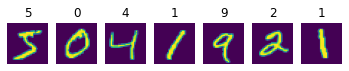

In [5]:
fig, ax = plt.subplots(1, 7)
for i in range(7):
    ax[i].imshow(data_train[i][0].view(28, 28))
    ax[i].set_title(data_train[i][1])
    ax[i].axis('off')

In [6]:
print("Training samples: ", len(data_train))
print("Test samples: ", len(data_test))

print("Tensor size: ", data_train[0][0].size())
print('First 10 digits are: ', [data_train[i][1] for i in range(10)])

Training samples:  60000
Test samples:  10000
Tensor size:  torch.Size([1, 28, 28])
First 10 digits are:  [5, 0, 4, 1, 9, 2, 1, 3, 1, 4]


In [7]:
print('Min intensity value: ', data_train[0][0].min().item())
print('Max intensity value: ', data_train[0][0].max().item())

Min intensity value:  0.0
Max intensity value:  1.0


In [12]:
from torch import nn
net = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28, 10),
    nn.LogSoftmax()
).to(device)

In [15]:
print('Digit to be predicted: ', data_train[0][1])
torch.exp(net(data_train[0][0].to(device)))

Digit to be predicted:  5


d:\projects\github_me\pytorch\LearnPyTorch\venv\lib\site-packages\torch\nn\modules\container.py:141: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  input = module(input)


tensor([[0.1053, 0.0900, 0.0816, 0.1169, 0.0730, 0.1118, 0.1236, 0.0760, 0.1169,
         0.1048]], device='cuda:0', grad_fn=<ExpBackward0>)

In [16]:
from torch.utils.data import DataLoader
train_loader = DataLoader(data_train, batch_size=64)
test_loader = DataLoader(data_test, batch_size=64)

In [17]:
def train_epoch(net,dataloader,lr=0.01,optimizer=None,loss_fn = nn.NLLLoss()):
    optimizer = optimizer or torch.optim.Adam(net.parameters(),lr=lr)
    net.train()
    total_loss,acc,count = 0,0,0
    for features,labels in dataloader:
        features, labels = features.to(device), labels.to(device)
        optimizer.zero_grad()
        out = net(features)
        loss = loss_fn(out,labels) #cross_entropy(out,labels)
        loss.backward()
        optimizer.step()
        total_loss+=loss
        _,predicted = torch.max(out,1)
        acc+=(predicted==labels).sum()
        count+=len(labels)
    return total_loss.item()/count, acc.item()/count

train_epoch(net,train_loader)

(0.005924585978190104, 0.8932666666666667)

In [18]:
def validate(net, dataloader, loss_fn=nn.NLLLoss()):
    net.eval()
    count, acc, loss = 0, 0, 0
    with torch.no_grad():
        for features, labels in dataloader:
            features, labels = features.to(device), labels.to(device)
            out = net(features)
            loss += loss_fn(out, labels)
            pred = torch.max(out, 1)[1]
            acc += (pred==labels).sum()
            count+=len(labels)
    return loss.item()/count, acc.item()/count

validate(net, test_loader)

d:\projects\github_me\pytorch\LearnPyTorch\venv\lib\site-packages\torch\nn\modules\container.py:141: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  input = module(input)


(0.005869033432006836, 0.8935)

In [20]:
def train(net, train_loader, test_loader, optimizer=None, lr=0.01, epochs=10, loss_fn=nn.NLLLoss()):
    optimizer = optimizer or torch.optim.Adam(net.parameters(), lr=lr)
    res = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }
    for ep in range(epochs):
        tl, ta = train_epoch(net, train_loader, lr, optimizer, loss_fn)
        vl, va = validate(net, test_loader, loss_fn)
        print(f"Epoch {ep:2}, Train acc={ta:.3f}, Val acc={va:.3f}, Train loss={tl:.3f}, Val loss={vl:.3f}")
        res['train_loss'].append(tl)
        res['train_acc'].append(ta)
        res['val_loss'].append(vl)
        res['val_acc'].append(va)
    return res

net = nn.Sequential(
        nn.Flatten(), 
        nn.Linear(784,10), # 784 inputs, 10 outputs
        nn.LogSoftmax()).to(device)

hist = train(net,train_loader,test_loader,epochs=5)

d:\projects\github_me\pytorch\LearnPyTorch\venv\lib\site-packages\torch\nn\modules\container.py:141: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  input = module(input)


Epoch  0, Train acc=0.892, Val acc=0.894, Train loss=0.006, Val loss=0.006
Epoch  1, Train acc=0.910, Val acc=0.899, Train loss=0.005, Val loss=0.006
Epoch  2, Train acc=0.913, Val acc=0.898, Train loss=0.005, Val loss=0.006
Epoch  3, Train acc=0.915, Val acc=0.897, Train loss=0.005, Val loss=0.006
Epoch  4, Train acc=0.916, Val acc=0.897, Train loss=0.005, Val loss=0.006


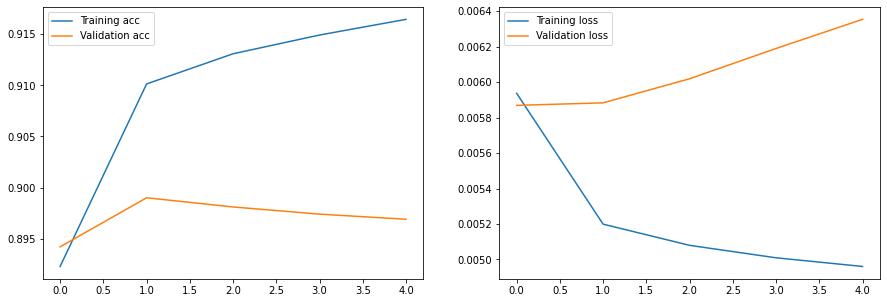

In [21]:
plt.figure(figsize=(15, 5))
plt.subplot(121)
plt.plot(hist['train_acc'], label="Training acc")
plt.plot(hist['val_acc'], label='Validation acc')
plt.legend()
plt.subplot(122)
plt.plot(hist['train_loss'], label='Training loss')
plt.plot(hist['val_loss'], label='Validation loss')
plt.legend()

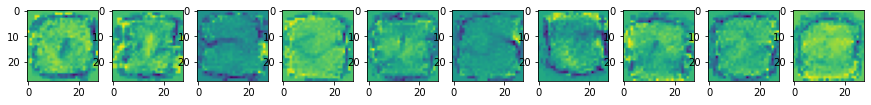

In [24]:
weight_tensor = next(net.parameters())
fig,ax = plt.subplots(1,10,figsize=(15,4))
for i,x in enumerate(weight_tensor):
    ax[i].imshow(x.cpu().view(28,28).detach())

In [25]:
net = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28, 100),
    nn.ReLU(),
    nn.Linear(100, 10),
    nn.LogSoftmax(dim=0)
).to(device)

from torchinfo import summary
summary(net, input_size=(1,28,28))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               --                        --
├─Flatten: 1-1                           [1, 784]                  --
├─Linear: 1-2                            [1, 100]                  78,500
├─ReLU: 1-3                              [1, 100]                  --
├─Linear: 1-4                            [1, 10]                   1,010
├─LogSoftmax: 1-5                        [1, 10]                   --
Total params: 79,510
Trainable params: 79,510
Non-trainable params: 0
Total mult-adds (M): 0.08
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.32
Estimated Total Size (MB): 0.32

In [34]:
from torch.nn.functional import relu, log_softmax
class MyNet(nn.Module):
    def __init__(self):
        super(MyNet, self).__init__()
        self.flatten = nn.Flatten()
        self.hidden = nn.Linear(28*28, 100)
        self.out = nn.Linear(100, 10)
    
    def forward(self, x):
        x = self.flatten(x)
        x = self.hidden(x)
        x = relu(x)
        x = self.out(x)
        x = log_softmax(x, dim=0)
        return x
net = MyNet().to(device)
summary(net, input_size=(1,28,28), device=device)
        

Layer (type:depth-idx)                   Output Shape              Param #
MyNet                                    --                        --
├─Flatten: 1-1                           [1, 784]                  --
├─Linear: 1-2                            [1, 100]                  78,500
├─Linear: 1-3                            [1, 10]                   1,010
Total params: 79,510
Trainable params: 79,510
Non-trainable params: 0
Total mult-adds (M): 0.08
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.32
Estimated Total Size (MB): 0.32

In [35]:
hist = train(net,train_loader,test_loader,epochs=5)

Epoch  0, Train acc=0.926, Val acc=0.946, Train loss=0.035, Val loss=0.034
Epoch  1, Train acc=0.951, Val acc=0.955, Train loss=0.033, Val loss=0.033
Epoch  2, Train acc=0.956, Val acc=0.953, Train loss=0.033, Val loss=0.033
Epoch  3, Train acc=0.961, Val acc=0.958, Train loss=0.033, Val loss=0.033
Epoch  4, Train acc=0.963, Val acc=0.958, Train loss=0.033, Val loss=0.033


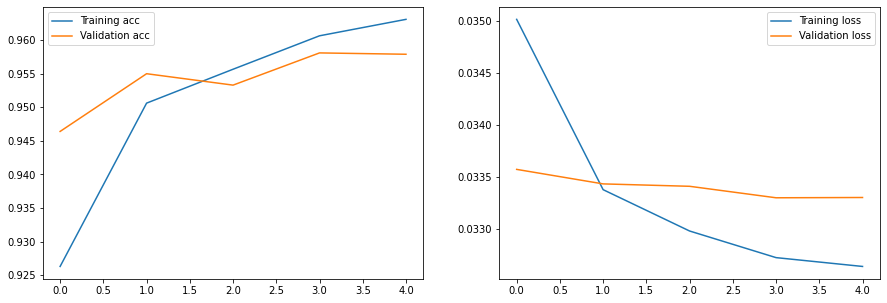

In [36]:
plt.figure(figsize=(15, 5))
plt.subplot(121)
plt.plot(hist['train_acc'], label="Training acc")
plt.plot(hist['val_acc'], label='Validation acc')
plt.legend()
plt.subplot(122)
plt.plot(hist['train_loss'], label='Training loss')
plt.plot(hist['val_loss'], label='Validation loss')
plt.legend()